## Importing Required Libraries:

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Load and Preprocess CIFAR-10
- Convert to tensor
- Normalize per channel (R, G, B)
- Flattening (32x32x3 → 3072) is done during training

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std =(0.2023, 0.1994, 0.2010)
    )
])

In [3]:
train_dataset = datasets.CIFAR10(root='./data', train=True,  transform=transform, download=True)
test_dataset  = datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]


In [4]:
CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

In [5]:
print(f"Train size : {len(train_dataset)}")
print(f"Test  size : {len(test_dataset)}")
print(f"Input dims : 32 x 32 x 3 = {32*32*3}")

Train size : 50000
Test  size : 10000
Input dims : 32 x 32 x 3 = 3072


## Sparse Autoencoder:

In [6]:
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim=3072, hidden_dim=1024,
                 sparsity_lambda=1e-4, sparsity_target=0.05):
        super(SparseAutoencoder, self).__init__()

        self.sparsity_lambda = sparsity_lambda
        self.sparsity_target = sparsity_target

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid()
        )

        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Tanh()
        )

        nn.init.xavier_uniform_(self.encoder[0].weight)
        nn.init.constant_(self.encoder[0].bias, 0)
        nn.init.xavier_uniform_(self.decoder[0].weight)
        nn.init.constant_(self.decoder[0].bias, 0)

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

    def kl_divergence_penalty(self, encoded):
        rho_hat = torch.mean(encoded, dim=0)
        rho     = self.sparsity_target
        eps     = 1e-8
        rho_hat = torch.clamp(rho_hat, min=eps, max=1 - eps)
        kl      = rho * torch.log(rho / rho_hat) + \
                  (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))
        return self.sparsity_lambda * torch.sum(kl)

    def loss(self, x, x_hat, encoded):
        recon_loss    = F.mse_loss(x_hat, x)
        sparsity_loss = self.kl_divergence_penalty(encoded)
        return recon_loss + sparsity_loss, recon_loss.item(), sparsity_loss.item()

## Train the model:

In [7]:
def train(model, loader, optimizer, epochs=20):
    model.train()
    model.to(device)
    history = []

    for epoch in range(1, epochs + 1):
        total_loss = 0.0

        for images, _ in loader:
            images = images.view(images.size(0), -1).to(device)

            optimizer.zero_grad()
            encoded, decoded = model(images)
            loss, _, _ = model.loss(images, decoded, encoded)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        avg = total_loss / len(loader)
        history.append(avg)
        print(f"Epoch [{epoch:>2}/{epochs}]  Loss: {avg:.4f}")

    return history

## Evaluate reconstruction loss on the test set:

In [8]:
def evaluate(model, loader):
    model.eval()
    total_mse = 0.0
    with torch.no_grad():
        for images, _ in loader:
            images = images.view(images.size(0), -1).to(device)
            encoded, decoded = model(images)
            total_mse += F.mse_loss(decoded, images).item()
    avg_mse = total_mse / len(loader)
    print(f"\nTest Reconstruction MSE: {avg_mse:.4f}")
    return avg_mse

## Visualise original vs reconstructed images:

In [9]:
MEAN = np.array([0.4914, 0.4822, 0.4465])
STD  = np.array([0.2023, 0.1994, 0.2010])

def denorm(img_tensor):
    img = img_tensor.permute(1, 2, 0).numpy()
    img = img * STD + MEAN
    return np.clip(img, 0, 1)

def visualise_reconstructions(model, loader, n=10):
    model.eval()
    images, labels = next(iter(loader))
    flat = images.view(images.size(0), -1).to(device)
    with torch.no_grad():
        _, recon = model(flat)
    recon = recon.cpu().view(-1, 3, 32, 32)

    fig, axes = plt.subplots(2, n, figsize=(n * 2, 5))
    fig.suptitle("Top: Original     Bottom: Reconstructed", fontsize=13, y=1.02)

    for i in range(n):
        axes[0, i].imshow(denorm(images[i]))
        axes[0, i].set_title(CLASSES[labels[i]], fontsize=8)
        axes[0, i].axis("off")

        axes[1, i].imshow(denorm(recon[i]))
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

## Sparsity regularisation experiment:

In [10]:
def sparsity_experiment(lambdas=(1e-5, 1e-4, 1e-3), epochs=10):
    results = {}

    for lam in lambdas:
        print(f"\n{'='*55}")
        print(f"  Training with sparsity_lambda = {lam}")
        print(f"{'='*55}")

        model = SparseAutoencoder(input_dim=3072, hidden_dim=1024,
                                  sparsity_lambda=lam)
        opt = torch.optim.Adam(model.parameters(), lr=1e-4)
        train(model, train_loader, opt, epochs=epochs)

        test_mse = evaluate(model, test_loader)

        model.eval()
        with torch.no_grad():
            imgs, _ = next(iter(test_loader))
            enc, _  = model(imgs.view(imgs.size(0), -1).to(device))
            sparse_frac = (enc.cpu() < 0.01).float().mean().item()

        results[lam] = {"mse": test_mse, "sparse_frac": sparse_frac}
        print(f"  Sparsity (near-zero fraction): {sparse_frac*100:.1f}%")

    print(f"{'Lambda':>12}  {'Test MSE':>10}  {'Sparsity %':>12}")
    for lam, r in results.items():
        print(f"{lam:>12.0e}  {r['mse']:>10.4f}  {r['sparse_frac']*100:>11.1f}%")
    print(f"{'='*52}")

    lam_list    = list(results.keys())
    mse_list    = [results[l]["mse"] for l in lam_list]
    sparse_list = [results[l]["sparse_frac"] * 100 for l in lam_list]

    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax2 = ax1.twinx()
    ax1.semilogx(lam_list, mse_list,    "o-",  color="steelblue", linewidth=2, label="Test MSE")
    ax2.semilogx(lam_list, sparse_list, "s--", color="tomato",    linewidth=2, label="Sparsity %")
    ax1.set_xlabel("Sparsity Lambda", fontsize=12)
    ax1.set_ylabel("Test MSE",                color="steelblue", fontsize=12)
    ax2.set_ylabel("Near-zero Activations %", color="tomato",    fontsize=12)
    ax1.tick_params(axis="y", labelcolor="steelblue")
    ax2.tick_params(axis="y", labelcolor="tomato")
    lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    lbls  = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
    ax1.legend(lines, lbls, loc="upper left")
    plt.title("Sparsity Lambda vs Reconstruction MSE and Activation Sparsity", fontsize=12)
    plt.tight_layout()
    plt.show()

    return results

## Build model:

In [11]:
model     = SparseAutoencoder(input_dim=3072, hidden_dim=1024, sparsity_lambda=1e-4, sparsity_target=0.05)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print(f"\nModel:\n{model}")
print(f"Total Parameters: {sum(p.numel() for p in model.parameters()):,}\n")


Model:
SparseAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=3072, out_features=1024, bias=True)
    (1): Sigmoid()
  )
  (decoder): Sequential(
    (0): Linear(in_features=1024, out_features=3072, bias=True)
    (1): Tanh()
  )
)
Total Parameters: 6,295,552



## Training:

In [16]:
print("Training the Sparse Autoencoder")
history = train(model, train_loader, optimizer, epochs=20)

Training the Sparse Autoencoder
Epoch [ 1/20]  Loss: 0.8363
Epoch [ 2/20]  Loss: 0.6047
Epoch [ 3/20]  Loss: 0.5422
Epoch [ 4/20]  Loss: 0.5070
Epoch [ 5/20]  Loss: 0.4830
Epoch [ 6/20]  Loss: 0.4657
Epoch [ 7/20]  Loss: 0.4524
Epoch [ 8/20]  Loss: 0.4418
Epoch [ 9/20]  Loss: 0.4331
Epoch [10/20]  Loss: 0.4257
Epoch [11/20]  Loss: 0.4193
Epoch [12/20]  Loss: 0.4139
Epoch [13/20]  Loss: 0.4089
Epoch [14/20]  Loss: 0.4048
Epoch [15/20]  Loss: 0.4010
Epoch [16/20]  Loss: 0.3974
Epoch [17/20]  Loss: 0.3944
Epoch [18/20]  Loss: 0.3916
Epoch [19/20]  Loss: 0.3890
Epoch [20/20]  Loss: 0.3866


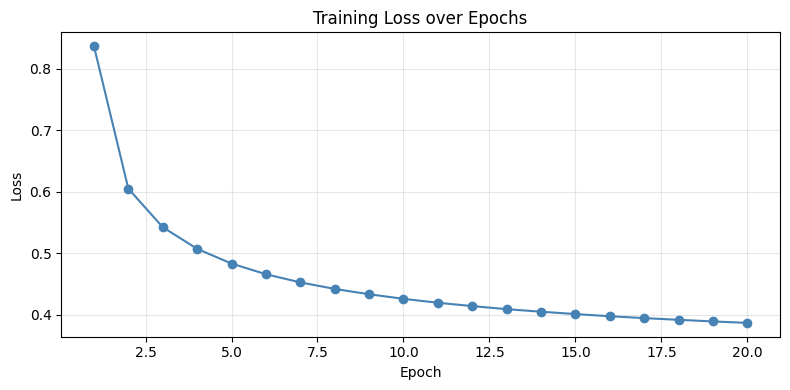

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history) + 1), history, marker="o", color="steelblue")
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Reconstruction Loss on Test Set:

In [18]:
print("Reconstruction Loss on Test Set")
evaluate(model, test_loader)

Reconstruction Loss on Test Set

Test Reconstruction MSE: 0.3592


0.35921977328348764

## Visualize:

Original vs Reconstructed Images


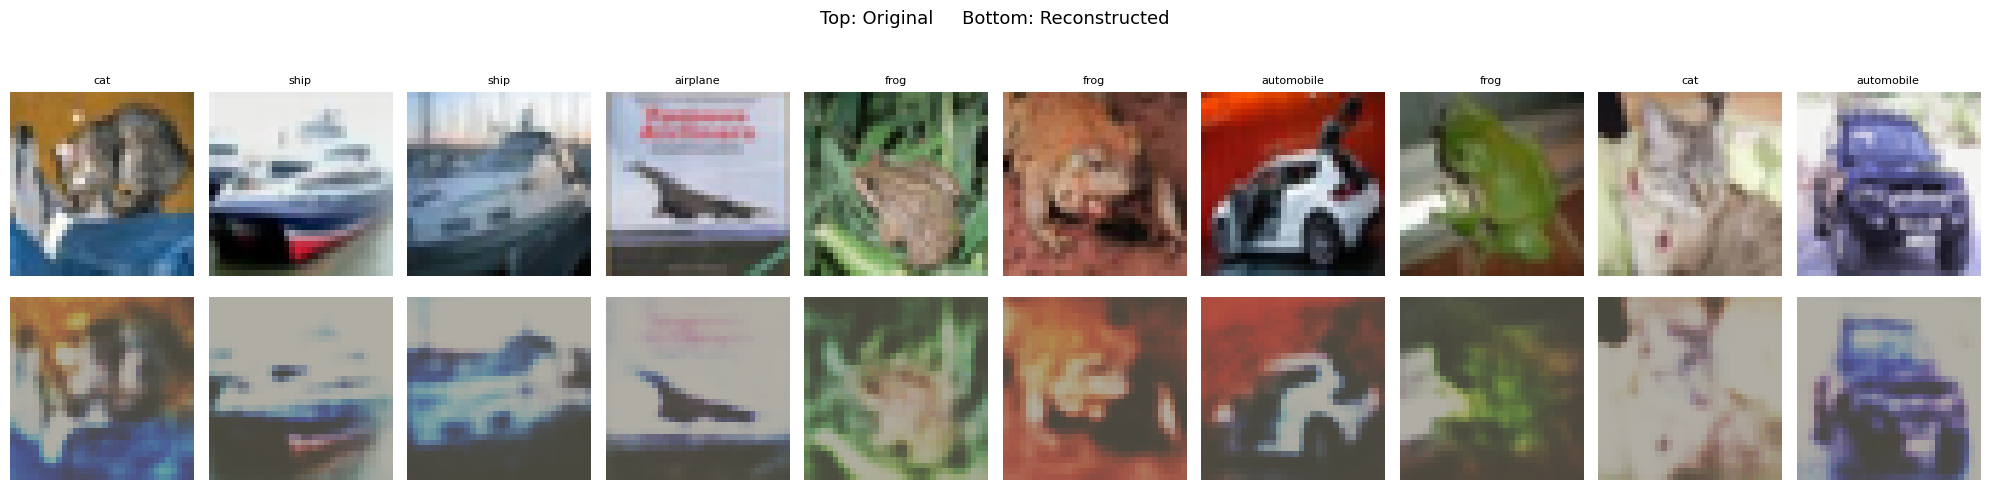

In [19]:
print("Original vs Reconstructed Images")
visualise_reconstructions(model, test_loader, n=10)

## Sparsity experiment:

Sparsity Regularisation Experiment

  Training with sparsity_lambda = 1e-05
Epoch [ 1/10]  Loss: 0.7933
Epoch [ 2/10]  Loss: 0.5647
Epoch [ 3/10]  Loss: 0.5035
Epoch [ 4/10]  Loss: 0.4690
Epoch [ 5/10]  Loss: 0.4460
Epoch [ 6/10]  Loss: 0.4296
Epoch [ 7/10]  Loss: 0.4171
Epoch [ 8/10]  Loss: 0.4072
Epoch [ 9/10]  Loss: 0.3992
Epoch [10/10]  Loss: 0.3925

Test Reconstruction MSE: 0.3870
  Sparsity (near-zero fraction): 3.6%

  Training with sparsity_lambda = 0.0001
Epoch [ 1/10]  Loss: 0.8361
Epoch [ 2/10]  Loss: 0.6046
Epoch [ 3/10]  Loss: 0.5419
Epoch [ 4/10]  Loss: 0.5066
Epoch [ 5/10]  Loss: 0.4828
Epoch [ 6/10]  Loss: 0.4656
Epoch [ 7/10]  Loss: 0.4523
Epoch [ 8/10]  Loss: 0.4418
Epoch [ 9/10]  Loss: 0.4330
Epoch [10/10]  Loss: 0.4257

Test Reconstruction MSE: 0.3897
  Sparsity (near-zero fraction): 6.0%

  Training with sparsity_lambda = 0.001
Epoch [ 1/10]  Loss: 1.1848
Epoch [ 2/10]  Loss: 0.9082
Epoch [ 3/10]  Loss: 0.8280
Epoch [ 4/10]  Loss: 0.7807
Epoch [ 5/10]  Loss: 0.7465

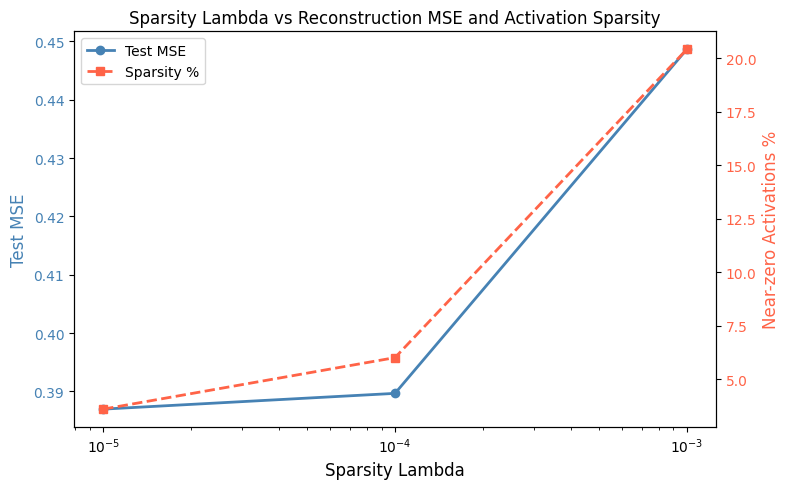

{1e-05: {'mse': 0.3869690148136284, 'sparse_frac': 0.03597259521484375},
 0.0001: {'mse': 0.3896715199645561, 'sparse_frac': 0.06005096435546875},
 0.001: {'mse': 0.44864196830157993, 'sparse_frac': 0.20417022705078125}}

In [20]:
print("Sparsity Regularisation Experiment")
sparsity_experiment(lambdas=(1e-5, 1e-4, 1e-3), epochs=10)